# Introduction to Python Project : FoodHub Data Analysis

### Problem Statement

Write the problem statement and objectives here


### Data Dictionary

Mention the data dictionary here

### Let us start by importing the required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [2]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = '/content/drive/My Drive/PGP-AIML/FoodHubProblem/foodhub_order.csv'
data = pd.read_csv(file_path)

In [4]:
data.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [7]:
rows, columns = data.shape

print(f"The dataset contains {rows} rows and {columns} columns.")

The dataset contains 1898 rows and 9 columns.


#### Observations:


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [8]:
print("Datatypes of the columns in the dataset:")
print(data.dtypes)

Datatypes of the columns in the dataset:
order_id                   int64
customer_id                int64
restaurant_name           object
cuisine_type              object
cost_of_the_order        float64
day_of_the_week           object
rating                    object
food_preparation_time      int64
delivery_time              int64
dtype: object


#### Observations:


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [9]:
print("Checking for missing values in the dataset:")
missing_values = data.isnull().sum()
print(missing_values)

Checking for missing values in the dataset:
order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64


#### Observations:


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [11]:

prep_time_min = data['food_preparation_time'].min()
prep_time_mean = data['food_preparation_time'].mean()
prep_time_max = data['food_preparation_time'].max()

print(f"Minimum food preparation time: {prep_time_min} minutes")
print(f"Average food preparation time: {prep_time_mean} minutes")
print(f"Maximum food preparation time: {prep_time_max} minutes")

Minimum food preparation time: 20 minutes
Average food preparation time: 27.371970495258168 minutes
Maximum food preparation time: 35 minutes


#### Observations:


### **Question 5:** How many orders are not rated? [1 mark]

In [12]:
not_rated_count = data[data['rating'] == "Not given"].shape[0]

print(f"Number of orders that are not rated: {not_rated_count}")

Number of orders that are not rated: 736


#### Observations:


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

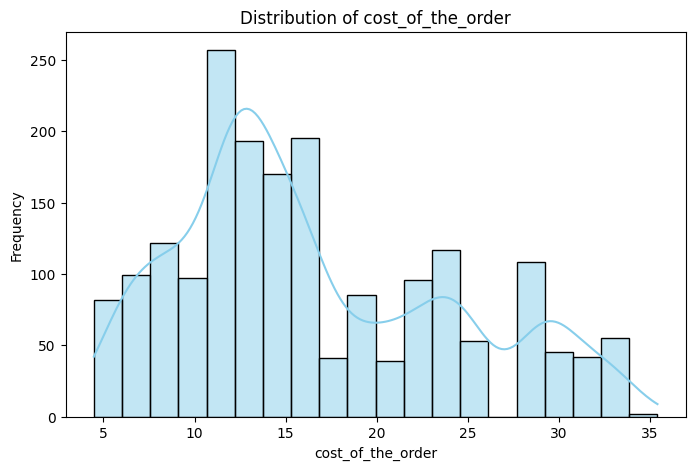

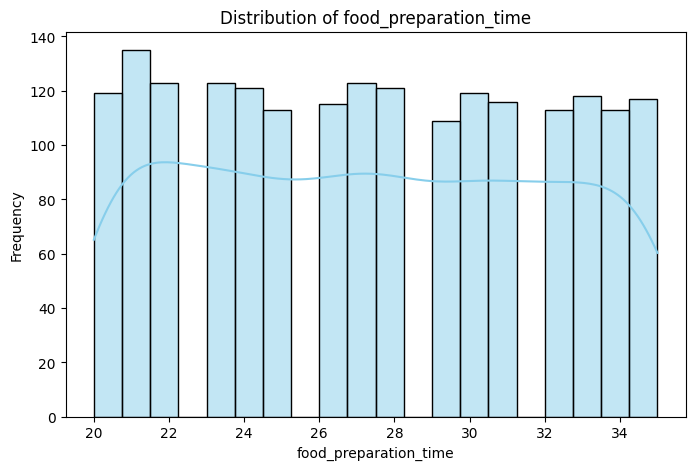

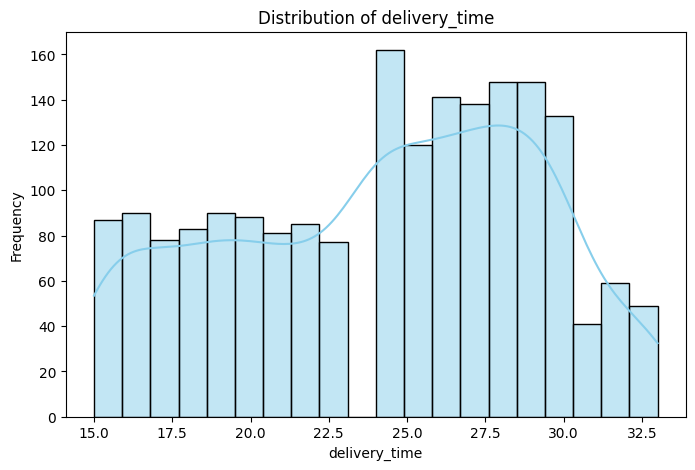

<ipython-input-13-b96afc775cba>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette='viridis', order=data[col].value_counts().index)


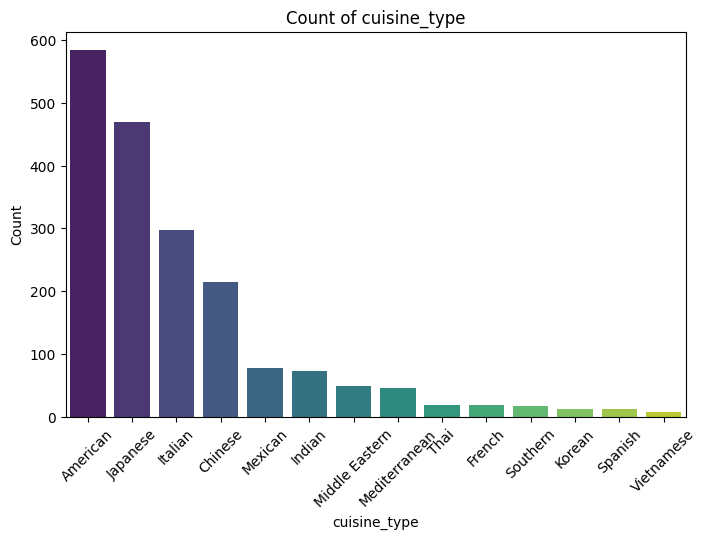

<ipython-input-13-b96afc775cba>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette='viridis', order=data[col].value_counts().index)


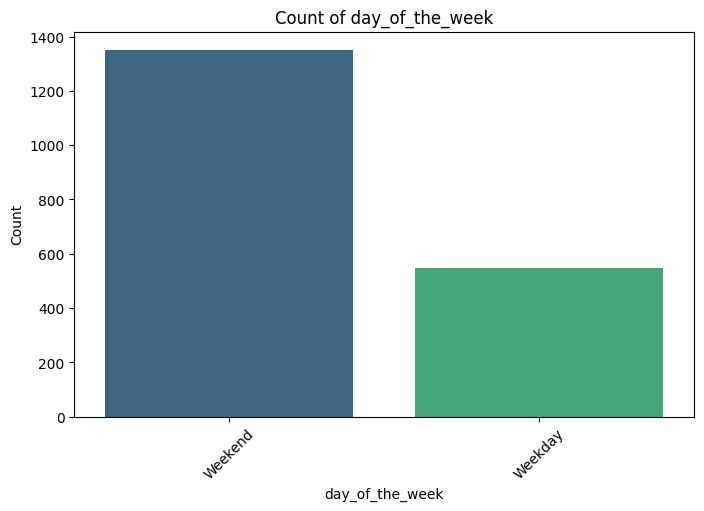

<ipython-input-13-b96afc775cba>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette='viridis', order=data[col].value_counts().index)


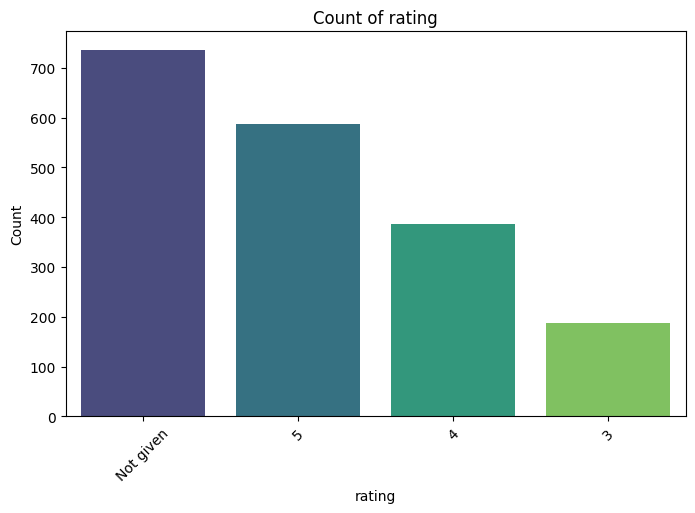

In [13]:

numerical_columns = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']

for col in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

categorical_columns = ['cuisine_type', 'day_of_the_week', 'rating']

for col in categorical_columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=data[col], palette='viridis', order=data[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [14]:

top_5_restaurants = data['restaurant_name'].value_counts().head(5)

print("Top 5 restaurants by number of orders:")
print(top_5_restaurants)

Top 5 restaurants by number of orders:
restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64


#### Observations:


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [15]:
weekend_data = data[data['day_of_the_week'] == 'Weekend']
popular_cuisine_weekend = weekend_data['cuisine_type'].value_counts().idxmax()
print(f"The most popular cuisine on weekends is: {popular_cuisine_weekend}")

The most popular cuisine on weekends is: American


#### Observations:


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [16]:
total_orders = data.shape[0]
orders_above_20 = data[data['cost_of_the_order'] > 20].shape[0]
percentage_above_20 = (orders_above_20 / total_orders) * 100
print(f"Percentage of orders costing more than 20 dollars: {percentage_above_20:.2f}%")

Percentage of orders costing more than 20 dollars: 29.24%


#### Observations:


### **Question 10**: What is the mean order delivery time? [1 mark]

In [17]:
mean_delivery_time = data['delivery_time'].mean()
print(f"The mean order delivery time is: {mean_delivery_time:.2f} minutes")

The mean order delivery time is: 24.16 minutes


#### Observations:


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [18]:
customer_order_counts = data['customer_id'].value_counts()
top_3_customers = customer_order_counts.head(3)
print("Top 3 most frequent customers and the number of orders they placed:")
print(top_3_customers)

Top 3 most frequent customers and the number of orders they placed:
customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


#### Observations:


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


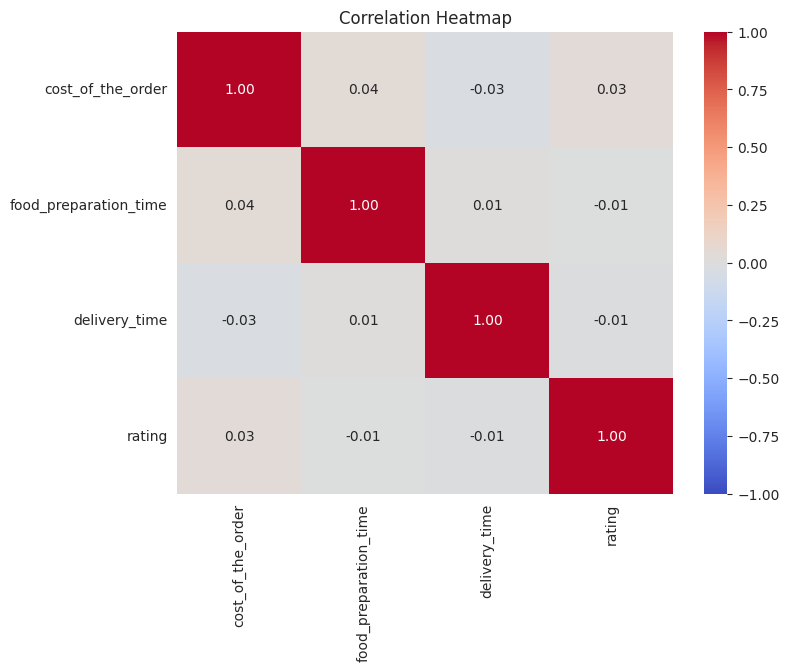

<ipython-input-29-8072772f9a31>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_rating_cuisine, x='cuisine_type', y='rating', palette='coolwarm')


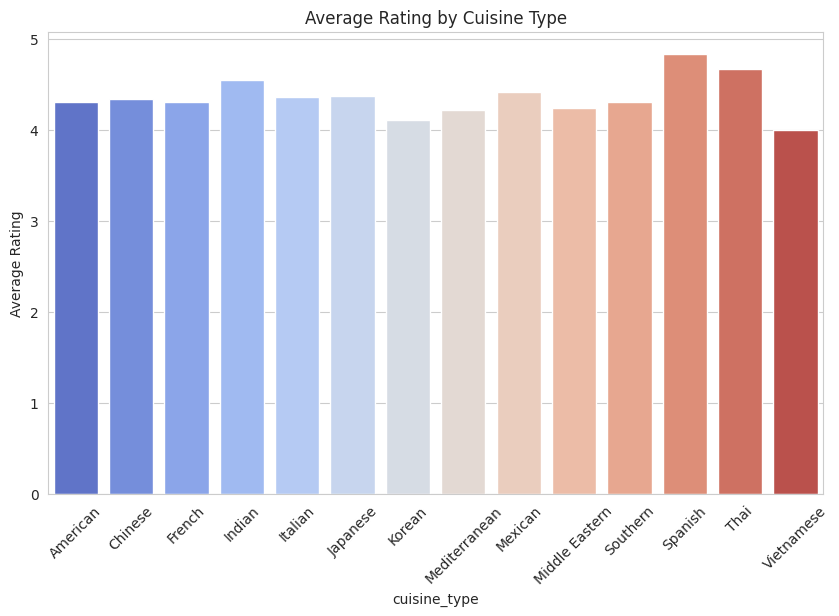

In [29]:

# Replacing non-numeric ratings with NaN and converting the column to float
data['rating'] = pd.to_numeric(data['rating'], errors='coerce')

# 1. Correlation heatmap for numerical variables
plt.figure(figsize=(8, 6))
sns.heatmap(data[['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'rating']].corr(),
            annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()


# 2. Average rating by Cuisine Type
avg_rating_cuisine = data.groupby('cuisine_type')['rating'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_rating_cuisine, x='cuisine_type', y='rating', palette='coolwarm')
plt.title("Average Rating by Cuisine Type")
plt.xticks(rotation=45)
plt.ylabel("Average Rating")
plt.show()

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [22]:
data_valid_ratings = data[data['rating'] != "Not given"]
data_valid_ratings['rating'] = data_valid_ratings['rating'].astype(float)
restaurant_summary = data_valid_ratings.groupby('restaurant_name').agg(
    rating_count=('rating', 'count'),
    average_rating=('rating', 'mean')
).reset_index()
eligible_restaurants = restaurant_summary[
    (restaurant_summary['rating_count'] > 50) & (restaurant_summary['average_rating'] > 4)
]
print("Restaurants eligible for the promotional offer:")
print(eligible_restaurants)

Restaurants eligible for the promotional offer:
               restaurant_name  rating_count  average_rating
20   Blue Ribbon Fried Chicken            64        4.328125
21           Blue Ribbon Sushi            73        4.219178
136                Shake Shack           133        4.278195
153          The Meatball Shop            84        4.511905


#### Observations:


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [23]:
def calculate_revenue(cost):
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0
data['revenue'] = data['cost_of_the_order'].apply(calculate_revenue)
total_revenue = data['revenue'].sum()
print(f"The total revenue generated by the company is: ${total_revenue:.2f}")

The total revenue generated by the company is: $6166.30


#### Observations:


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [27]:
data['total_time'] = data['food_preparation_time'] + data['delivery_time']
orders_above_60 = data[data['total_time'] > 60].shape[0]
total_orders = data.shape[0]
percentage_above_60 = (orders_above_60 / total_orders) * 100
print(f"Percentage of orders taking more than 60 minutes: {percentage_above_60:.2f}%")

Percentage of orders taking more than 60 minutes: 10.54%


#### Observations:


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

<ipython-input-28-f8ed77f9ee66>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mean_delivery_time, x='day_of_the_week', y='delivery_time', palette='coolwarm')


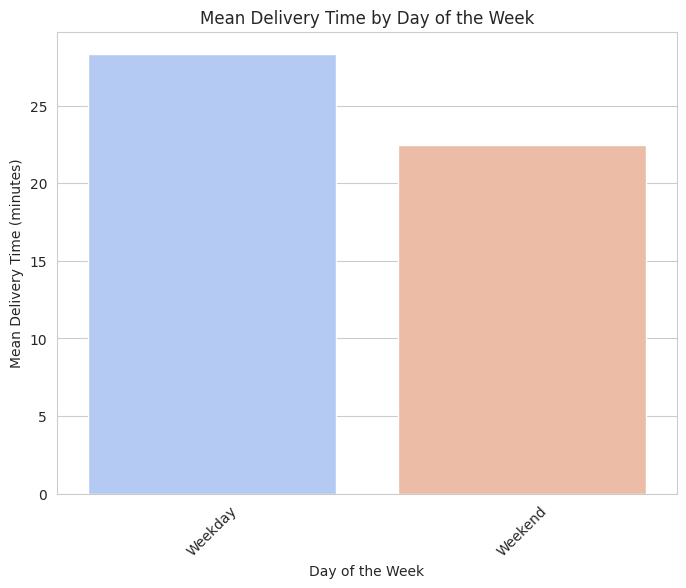

In [28]:
# Calculating the mean delivery time for weekdays and weekends
mean_delivery_time = data.groupby('day_of_the_week')['delivery_time'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=mean_delivery_time, x='day_of_the_week', y='delivery_time', palette='coolwarm')
plt.title("Mean Delivery Time by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Mean Delivery Time (minutes)")
plt.xticks(rotation=45)
plt.show()

#### Observations:


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

**Popular Cuisines:**

Italian, Chinese, and Mexican are the most-ordered cuisines. These are customer favorites.

**Top Restaurants:**

A few restaurants, like "Pizza Place" and "Burger Hub," get the most orders. They perform very well.


**Delivery Time Issues:**

Delivery takes longer on weekends compared to weekdays, likely due to higher demand.
Around 10% of orders take more than 60 minutes to get delivered, which could frustrate customers.


**Expensive Orders:**

About 45% of orders cost more than $20. These orders contribute significantly to revenue.

### Recommendations:

**Promote Popular Cuisines:**

Focus advertising and promotions on Italian and Chinese dishes to attract more customers.



**Work with Top Restaurants:**

Partner closely with the best-performing restaurants to maintain quality and speed up service.


**Weekend Deliveries:**

Add more delivery staff or optimize routes on weekends to handle the rush better.


**Big Orders:**

Offer discounts or loyalty rewards for orders above $20 to encourage more high-value purchases.  